In [99]:
import json
import pandas as pd
from io import StringIO

with open('../data/highest_result.json', 'r') as file:
    data = json.load(file)

activities_str = data['activitiesLog']

df = pd.read_csv(StringIO(activities_str), sep=';')

df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.000000
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.000000
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.000000
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.000000
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,-1,199700,EMERALDS,9992,14,9990,28,NaN,NaN,10008,14,10010,28,NaN,NaN,10000.0,883.000000
3996,-1,199800,EMERALDS,9992,15,9990,27,NaN,NaN,10008,15,10010,27,NaN,NaN,10000.0,883.000000
3997,-1,199800,TOMATOES,4989,8,4987,25,NaN,NaN,5002,8,5003,25,NaN,NaN,4995.5,1330.828125
3998,-1,199900,TOMATOES,4990,10,4989,15,NaN,NaN,5003,10,5005,15,NaN,NaN,4996.5,1350.585938


In [100]:
df["spread_1"] = df["ask_price_1"] - df["bid_price_1"]
df.head(2)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread_1
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.0,14
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0,16


In [101]:
product_results_eme = df[df['product']=='EMERALDS']
product_results_tom = df[df['product']=='TOMATOES']

In [102]:
import matplotlib.pyplot as plt

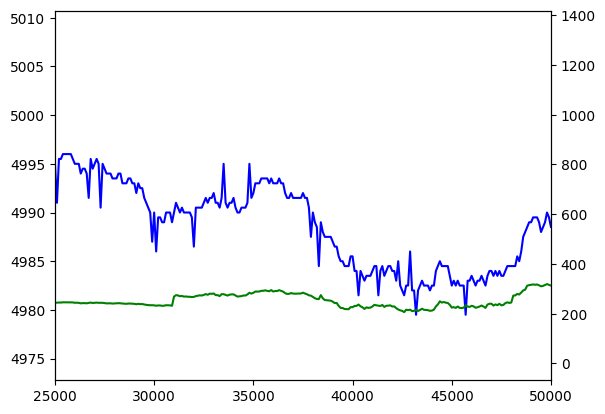

In [134]:
x_val = product_results_eme["timestamp"]
y1_vals = (product_results_tom["mid_price"])
y2_vals = (product_results_tom["profit_and_loss"])

fig, ax1 = plt.subplots()
plt.plot(x_val, y1_vals, 'b', lw=1.5, label='1st')
ax1.set_xlim(25000, 50000)
#plt.plot(y1_vals, 'ro')
#plt.legend(loc=8)

ax2 = ax1.twinx()
plt.plot(x_val, y2_vals, 'g', lw=1.5, label='2nd')
#plt.plot(y2_vals, 'ro')
#plt.legend(loc=0)

plt.show()

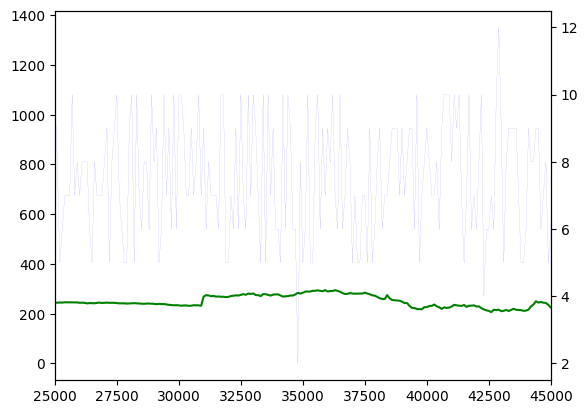

In [ ]:
x = product_results_eme["timestamp"]
y1 = product_results_tom['profit_and_loss']
y2 = product_results_tom['bid_volume_1']

fig, ax1 = plt.subplots()
plt.plot(x, y1, 'g', lw=1.5)
ax1.set_xlim(25000, 45000)

ax2 = ax1.twinx()
plt.plot(x, y2, 'b', lw=.05)

plt.show()


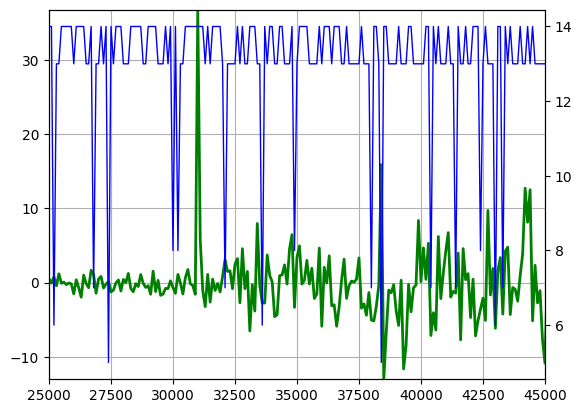

In [167]:
import numpy as np
import matplotlib.pyplot as plt

x = product_results_eme["timestamp"].to_numpy()
y1 = product_results_tom["profit_and_loss"].diff().to_numpy()
y2 = product_results_tom["spread_1"].shift(1).to_numpy()

start = 25000
end = 45000

mask = (x >= start) & (x <= end)
y1_zoom = y1[mask]

fig, ax1 = plt.subplots()

ax1.plot(x, y1, 'g', lw=2, zorder=3)
ax1.set_xlim(start, end)
ax1.set_ylim(y1_zoom.min(), y1_zoom.max())

ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x, y2, 'b', lw=1, zorder=1)

plt.show()

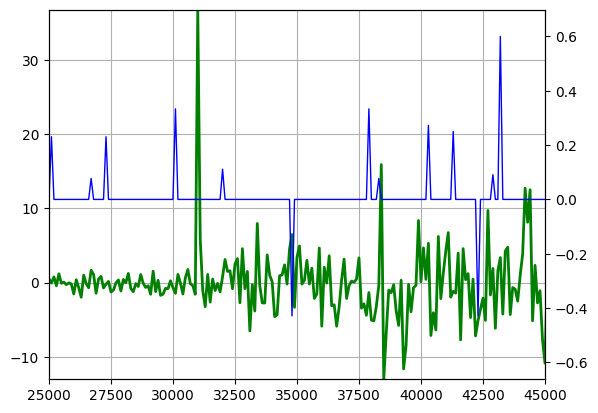

In [164]:
product_results_tom['lev_1_vol'] = (product_results_tom['bid_volume_1'] + 
                                    product_results_tom['ask_volume_1'])
product_results_tom['order_regime'] = ((product_results_tom['bid_volume_1'] - 
                                       product_results_tom['ask_volume_1']) /
                                       (product_results_tom['bid_volume_1'] +
                                       product_results_tom['ask_volume_1']))

x = product_results_eme["timestamp"].to_numpy()
y1 = product_results_tom["profit_and_loss"].diff().to_numpy()
y2 = product_results_tom['order_regime'].to_numpy()

start = 25000
end = 45000

mask = (x >= start) & (x <= end)
y1_zoom = y1[mask]

fig, ax1 = plt.subplots()

ax1.plot(x, y1, 'g', lw=2, zorder=3)
ax1.set_xlim(start, end)
ax1.set_ylim(y1_zoom.min(), y1_zoom.max())

ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x, y2, 'b', lw=1, zorder=1)

plt.show()

In [163]:
corr = product_results_tom['order_regime'].shift(1).corr(product_results_tom['mid_price'].diff())
print(corr)

0.2669925457523248


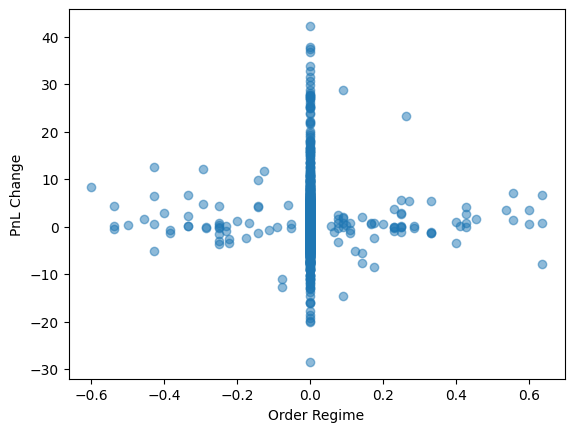

In [162]:
import matplotlib.pyplot as plt

plt.scatter(product_results_tom['order_regime'], product_results_tom['profit_and_loss'].diff(), alpha=.5)
plt.xlabel("Order Regime")
plt.ylabel("PnL Change")
plt.show()